In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor
%env TENSORLY_BACKEND=numpy

import tensorly as tl
import plotly.io as pio
pio.renderers.default = 'iframe'


print(f'TensorLy backend: {tl.get_backend()}')
print(f'TensorLy tenalg backend: {tl.tenalg.get_backend()}')

env: CUPY_ACCELERATORS=cutensor
env: TENSORLY_BACKEND=numpy
TensorLy backend: numpy
TensorLy tenalg backend: core


In [2]:
from moabb.paradigms import FilterBankMotorImagery, MotorImagery
from moabb.datasets import *
from hoda.tensorize import fh_power, fh_log_envelope
from hoda.classification import ZLogRatio, ZScore
dataset = Schirrmeister2017()
dataset.event_id




{'right_hand': 1, 'left_hand': 2, 'rest': 3, 'feet': 4}

In [3]:
events = list(dataset.event_id.keys())[:3]
events

['right_hand', 'left_hand', 'rest']

In [4]:
sfreq=250
paradigm = MotorImagery(events=events, n_classes=3, resample=sfreq)
paradigm.used_events(dataset)

{'right_hand': 1, 'left_hand': 2, 'rest': 3}

In [5]:
from sklearn.preprocessing import FunctionTransformer
import sys
sys.path.append('../')
from classification_mi import stf_transform 

cache_config = dict(
    use=True,
    save_raw=False,
    save_epochs=False,
    save_array=True,
    overwrite_raw=False,
    overwrite_epochs=False,
    overwrite_array=False,
)

X, y, meta = paradigm.get_data(
     dataset=dataset, 
     subjects=[1],
     return_epochs=False,
     postprocess_pipeline = FunctionTransformer(stf_transform),
     cache_config=cache_config,

)



In [6]:
X.shape

(360, 128, 16, 48)

In [7]:
import numpy as np
np.unique(y)

array(['left_hand', 'rest', 'right_hand'], dtype='<U10')

In [8]:
X = tl.tensor(X)
X = ZScore().fit_transform(X)

In [9]:
import plotly.express as px
import numpy as np

px.imshow(np.cov(tl.to_numpy(tl.unfold(X,1))))

In [10]:
px.imshow(np.cov(tl.to_numpy(tl.unfold(X,2))))

In [11]:
px.imshow(np.cov(tl.to_numpy(tl.unfold(X,3))), color_continuous_scale='RdBu_r', zmin=-1.5, zmax=1.5)

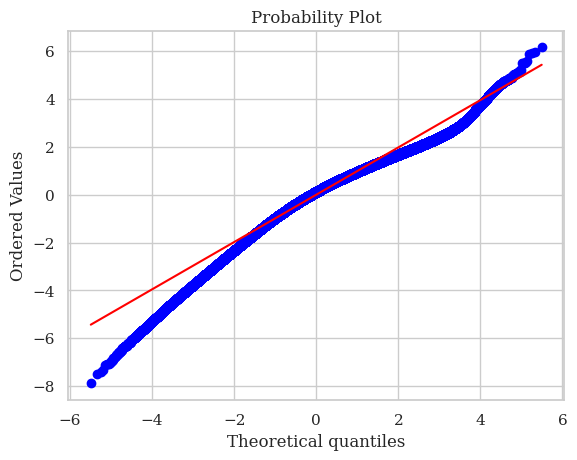

In [12]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as stats
import matplotlib
%matplotlib inline

measurements = np.random.normal(loc = 20, scale = 5, size=100)   
stats.probplot(tl.to_numpy(X).flatten(), dist="norm", plot=plt)
plt.show()


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

#x_mean = tl.to_numpy(X_tfr_base[y=='feet']).mean(axis=0)
#for f in range(x_mean.shape[0]):
#    sns.heatmap(x_mean[f], cmap='RdBu_r', center=0, square='True')
#    plt.show()

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd

x = tl.to_numpy(X.flatten())
hist, bin_edges = np.histogram(x, bins=100000)
bins = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute the mean of each subsequent pair
df = pd.DataFrame({'bins':bins, 'count':hist})
px.histogram(df, x="bins", y="count")

In [15]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=256,
        tol=1e-6,
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        forward=True,
        theta=0.5,
        refit_shrinkage=True,
)


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from hoda.util import solve_gevdh
from hoda.cov import mode_scatter, ledoit_wolf_shrinkage

plt.style.use('default')
%load_ext line_profiler

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

Backward HODA model rank=(4, 4, 8):   9%|▉         | 23/256 [00:11<01:51,  2.09it/s]


,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.389954e+00,0.000965,6.106174e+06
1,1,2,2,1.414473e+00,0.005511,7.242231e+06
2,1,3,3,1.412472e+00,0.032798,4.643161e+06
3,2,1,4,1.294191e+00,0.016752,2.380125e+06
4,2,2,5,9.961940e-01,0.024656,6.005450e+06
...,...,...,...,...,...,...
67,23,2,68,5.696756e-07,0.028501,5.908010e+06
68,23,3,69,7.214043e-07,0.042487,4.437370e+06
69,24,1,70,7.758614e-07,0.020137,5.269104e+05
70,24,2,71,3.157253e-07,0.028501,5.908011e+06


In [17]:
from hoda.classification import SelectFCutoff
Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt, 0))
print(xt.shape)
select = SelectFCutoff()
select.fit(xt,y)
print(select.support_)

(360, 128)
[False False False False False False False  True False  True False False
 False  True  True False False False False False False  True False False
 False False False False False  True False False False False  True False
 False False False False False  True False False False  True False False
 False False False False  True False  True False  True  True False  True
 False False False  True False False False  True  True  True  True False
 False False False  True False  True False  True False False  True  True
 False  True  True  True  True  True  True False  True  True  True  True
  True  True False  True  True False False False False False  True False
 False  True False  True  True False  True  True  True False  True False
  True False  True False False False False  True]


In [18]:
# 0.270325 s, 42.8%

In [19]:
import plotly.express as px

px.imshow(tl.to_numpy(hoda.scatter_w_[0]))

In [20]:
import plotly.express as px

px.imshow(tl.to_numpy(hoda.scatter_w_[1]))

In [21]:
import plotly.express as px

px.imshow(tl.to_numpy(hoda.scatter_w_[2]))

In [22]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.389954e+00,0.000965,6.106174e+06
1,1,2,2,1.414473e+00,0.005511,7.242231e+06
2,1,3,3,1.412472e+00,0.032798,4.643161e+06
3,2,1,3,1.294191e+00,0.016752,2.380125e+06
4,2,2,4,9.961940e-01,0.024656,6.005450e+06
...,...,...,...,...,...,...
67,23,2,46,5.696756e-07,0.028501,5.908010e+06
68,23,3,47,7.214043e-07,0.042487,4.437370e+06
69,24,1,47,7.758614e-07,0.020137,5.269104e+05
70,24,2,48,3.157253e-07,0.028501,5.908011e+06


In [23]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr', log_y=False)
    fig.show()

In [24]:
px.line(df, x='iteration', y='update', log_y=True, color='mode')


In [25]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

In [26]:
px.line(df, x='flip', y='objective', log_y=False, color='mode')

In [27]:
%load_ext line_profiler
%lprun -f hoda.fit_forward hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


Forward model :  41%|████      | 104/255 [01:00<01:27,  1.72it/s]


,iteration,mode,flip,update
0,1,1,1,1.070223e+00
1,1,2,2,7.016032e-01
2,1,3,3,1.595662e+00
3,2,1,4,8.067478e-01
4,2,2,5,5.662876e-01
...,...,...,...,...
310,104,2,311,8.047515e-07
311,104,3,312,9.125874e-07
312,105,1,313,8.745386e-07
313,105,2,314,7.005054e-07


Timer unit: 1e-09 s

Total time: 60.4681 s
File: /vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/hoda.py
Function: fit_forward at line 359

Line #      Hits         Time  Per Hit   % Time  Line Contents
   359                                               def fit_forward(self, X, y, X_centered=None, Xt=None):
   360         1      80502.0  80502.0      0.0          X, y = validate(X, y)
   361                                           
   362         1       3247.0   3247.0      0.0          n_samples, *shape = X.shape
   363         1        910.0    910.0      0.0          order = len(shape)
   364                                           
   365                                                   # Project
   366         1        184.0    184.0      0.0          if Xt is None:
   367         1  102354098.0    1e+08      0.2              Xt = self.transform(X)
   368                                           
   369                                                   # Initi

In [28]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,flip,update
0,1,1,1,1.070223e+00
1,1,2,2,7.016032e-01
2,1,3,3,1.595662e+00
3,2,1,3,8.067478e-01
4,2,2,4,5.662876e-01
...,...,...,...,...
310,104,2,208,8.047515e-07
311,104,3,209,9.125874e-07
312,105,1,209,8.745386e-07
313,105,2,210,7.005054e-07


In [29]:
if hoda.extra_train_info:
    x.line(df, x='flip', y='mse', log_y=True)

In [30]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

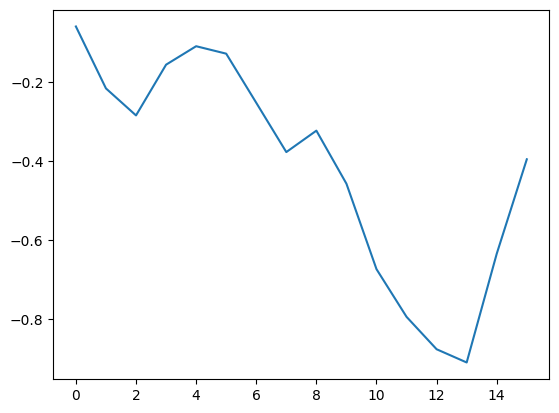

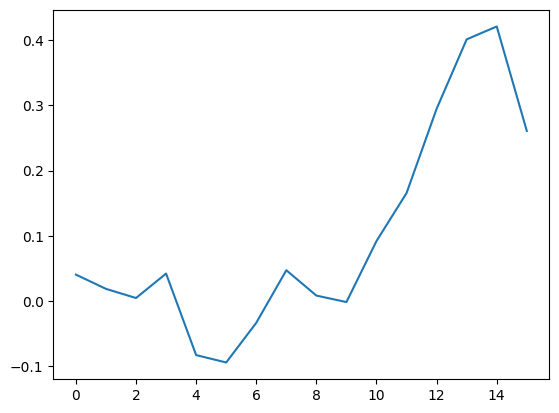

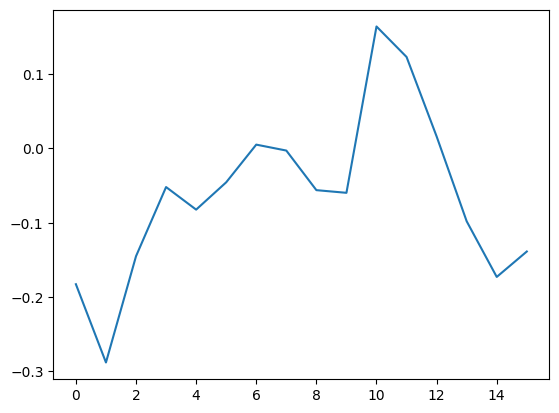

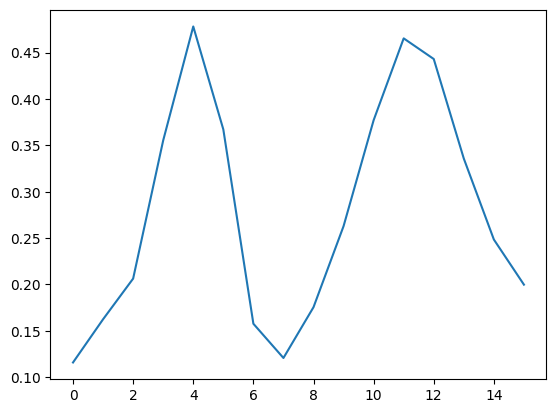

In [31]:
for i in range(hoda.weights_[1].shape[1]):
    plt.plot(tl.to_numpy(hoda.aps_[1][:,i]))
    plt.show()

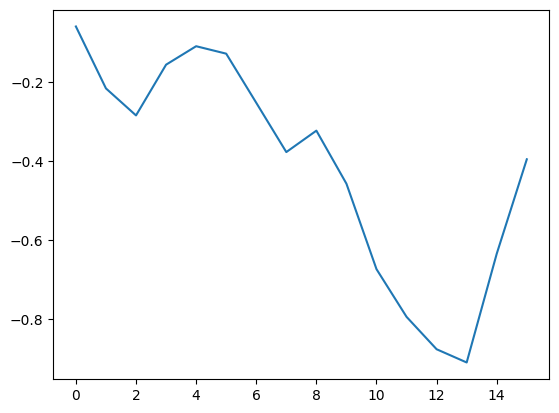

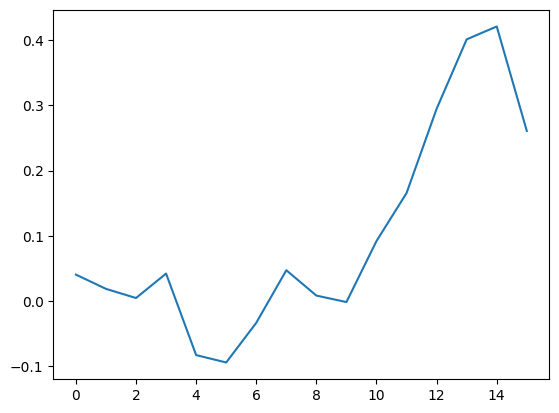

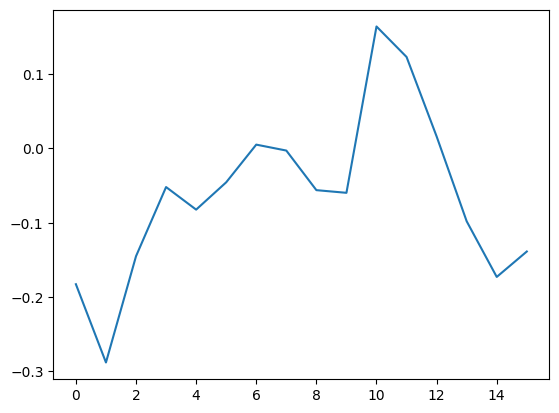

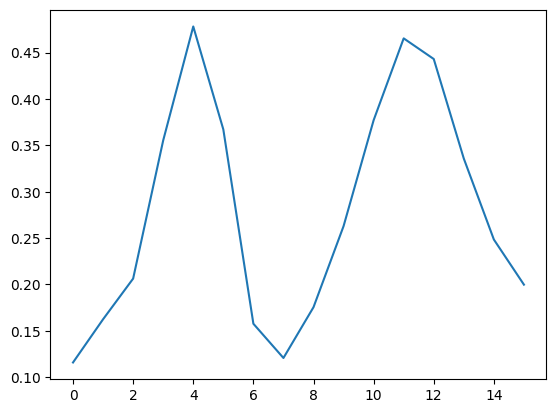

In [32]:
for i in range(hoda.aps_[1].shape[1]):
    plt.plot(tl.to_numpy(hoda.aps_[1][:,i]))
    plt.show()

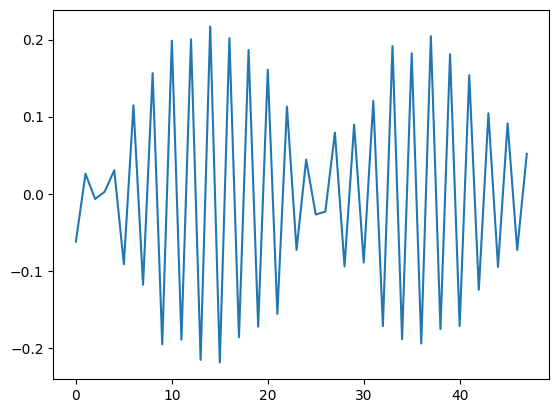

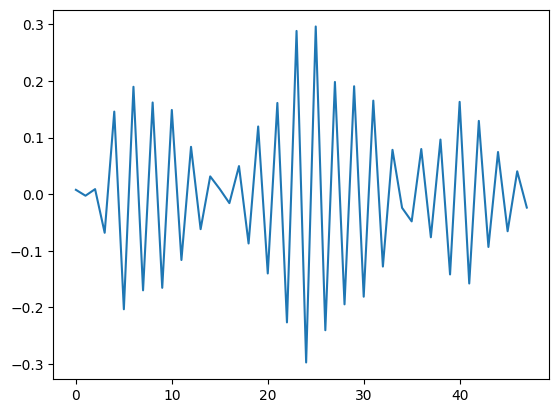

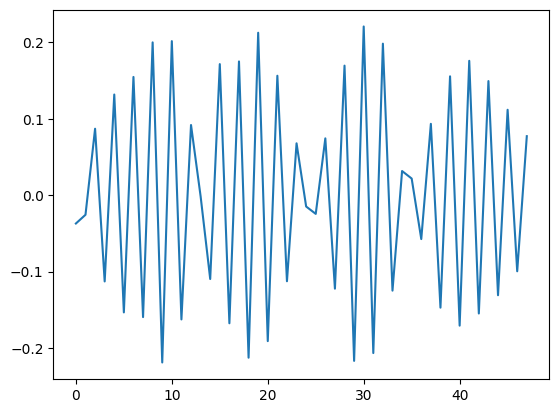

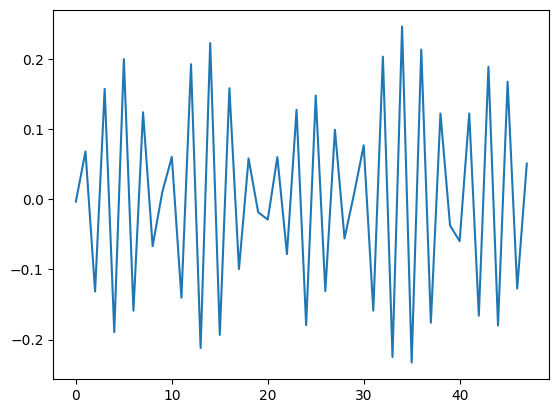

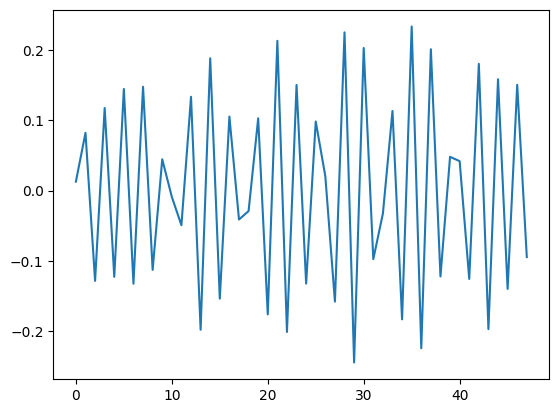

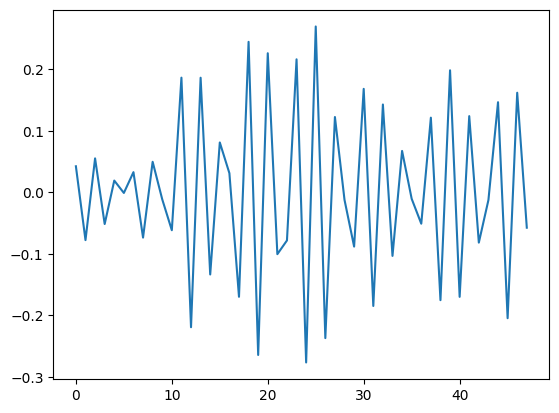

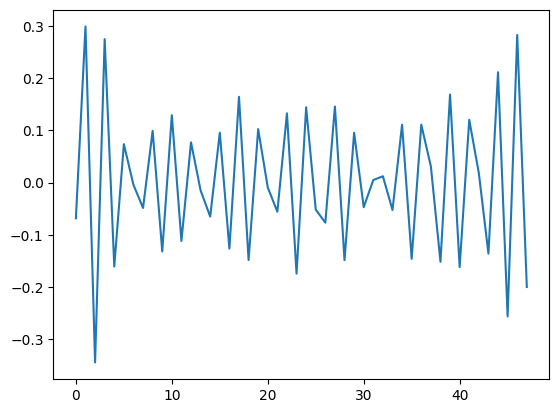

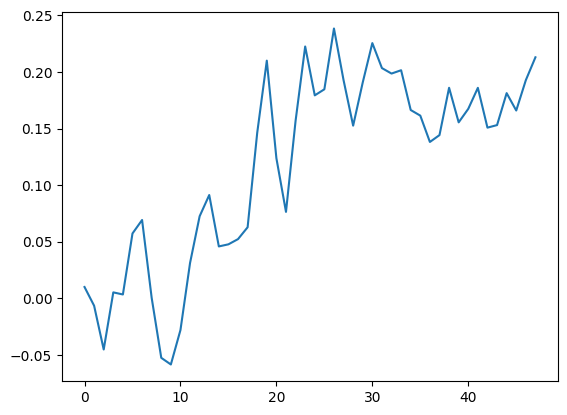

In [33]:
for i in range(hoda.weights_[2].shape[1]):
    plt.plot(tl.to_numpy(hoda.weights_[2][:,i]))
    plt.show()

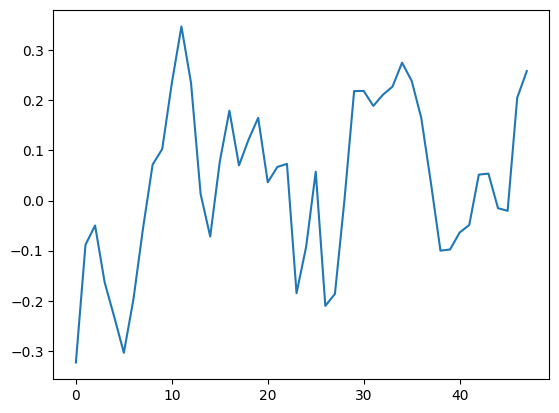

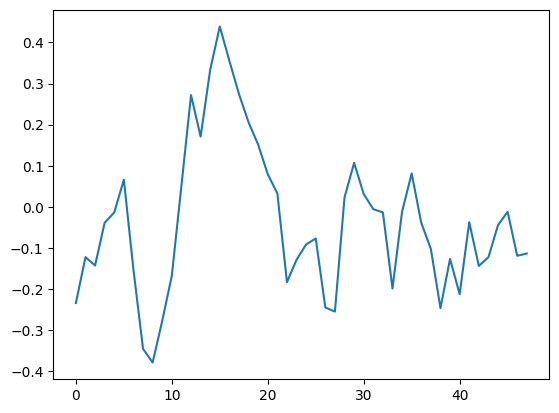

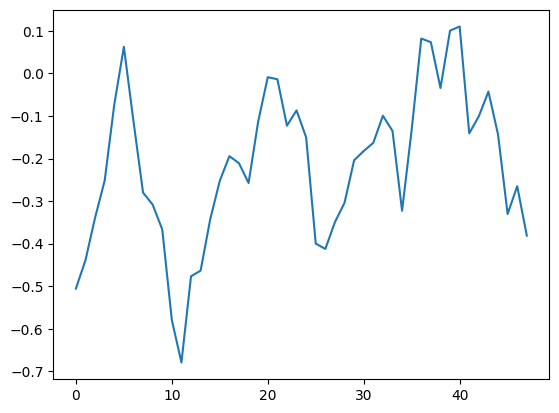

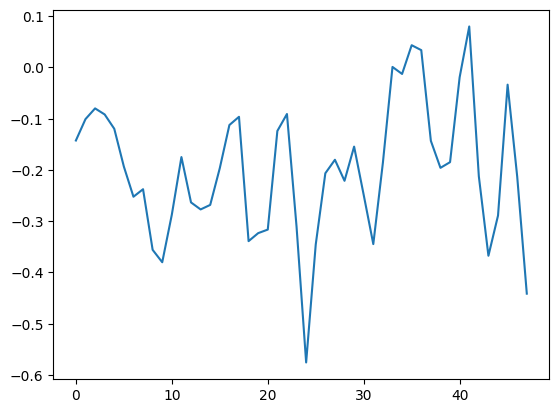

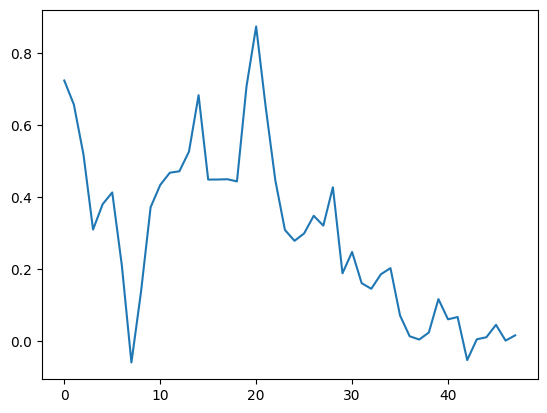

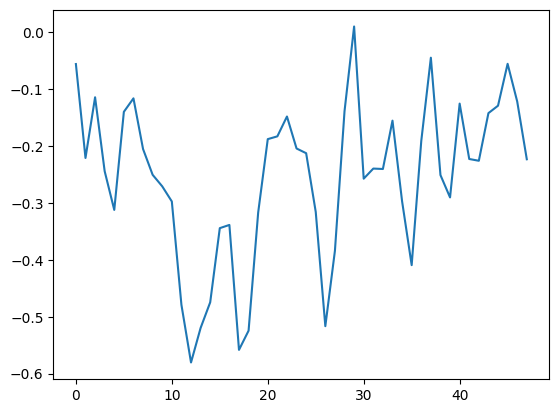

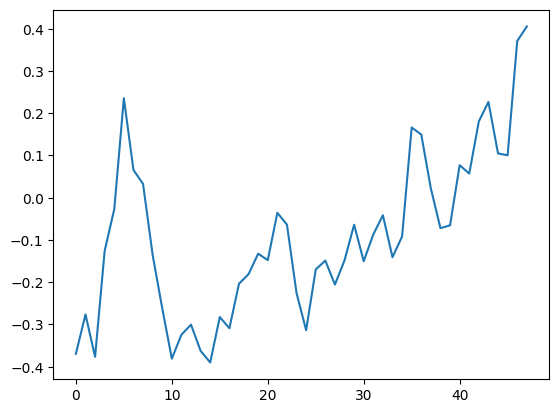

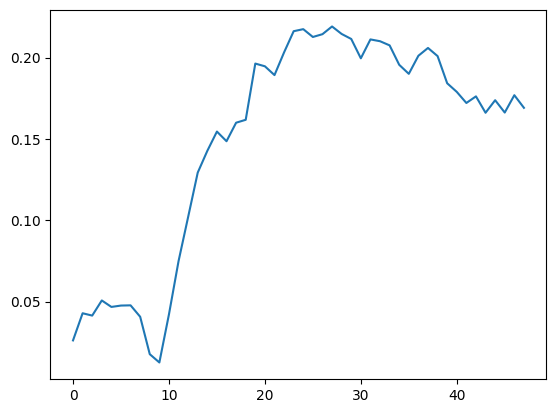

In [34]:
for i in range(hoda.aps_[2].shape[1]):
    plt.plot(tl.to_numpy(hoda.aps_[2][:,i]))
    plt.show()

In [35]:
from sklearn.feature_selection import f_classif
import numpy as np
from sklearn.decomposition import PCA
Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))
F, p = f_classif(xt, y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': F,
    'selected': F>1
})
fig = px.bar(df, x='feature', y='F', color='selected', log_y=True)
fig.show()

In [36]:
from sklearn.feature_selection import f_classif
import numpy as np
from sklearn.decomposition import PCA
Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))
F, p = f_classif(xt, y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': F,
    'selected': F>1
})
fig = px.bar(df, x='feature', y='F', color='selected', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [37]:
Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))


xt_pca = PCA(whiten=True, n_components=None).fit_transform(xt)
F_pca, p = f_classif(xt_pca, y)

df = pd.DataFrame({
    'feature': np.arange(len(F_pca)),
    'F': F_pca,
    'selected': F_pca>1
})
fig = px.bar(df, y='F', color='selected', log_y=True)
fig.show()

In [38]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


fig = px.scatter(x=xt_pca[:,0], y=xt_pca[:,1], color=y)
fig.update_layout(width=1000, height=800)

### 